In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from scipy.spatial.distance import cdist

In [2]:
data = pd.read_csv("loan_data.csv")

cat_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]
encoder = LabelEncoder()
for col in cat_cols:
    data[col] = encoder.fit_transform(data[col])

In [3]:
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,6,3,15000,3,15.66,0.31,3,645,0,1
44996,37,0,0,65800,17,3,9000,2,14.07,0.14,11,621,0,1
44997,33,1,0,56942,7,3,2771,0,10.02,0.05,10,668,0,1
44998,29,1,1,33164,4,3,12000,1,13.23,0.36,6,604,0,1


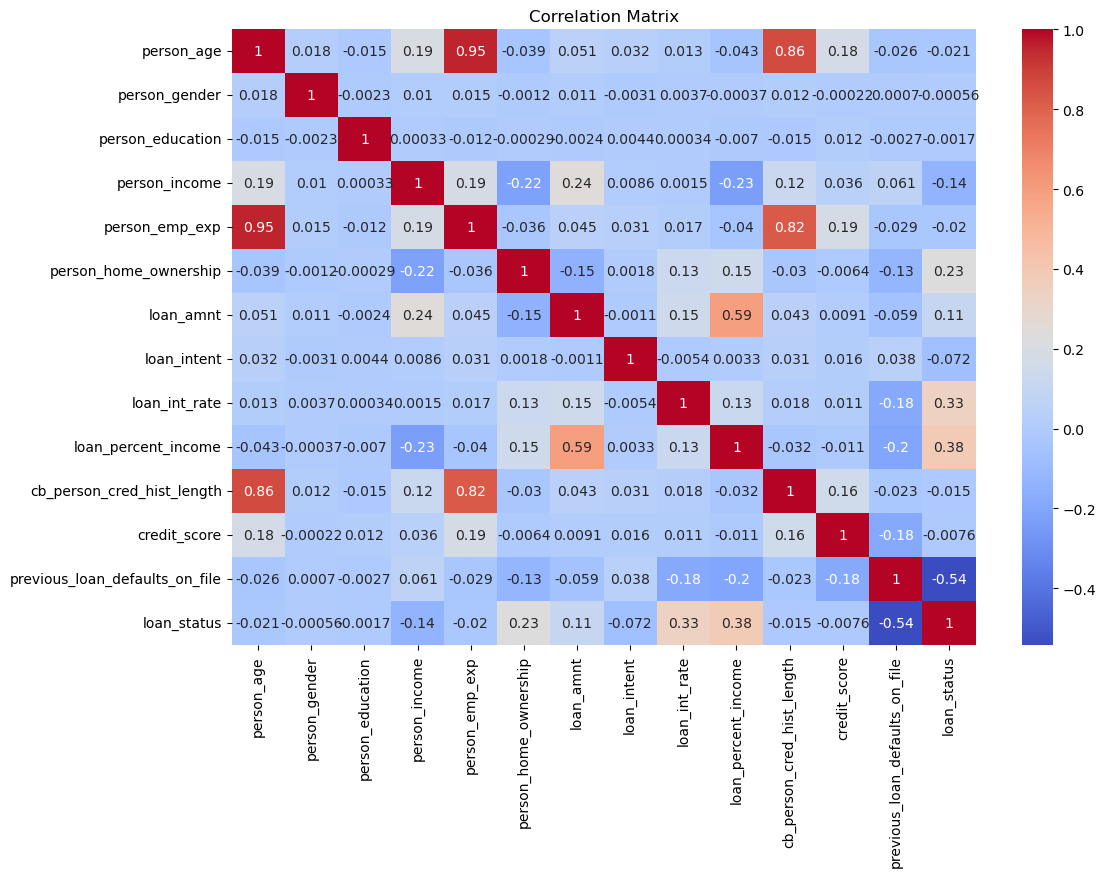

In [4]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [5]:
data.drop(columns = ['person_emp_exp'], inplace=True)
data

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,3,35000,3,14.27,0.53,4,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,3,645,0,1
44996,37,0,0,65800,3,9000,2,14.07,0.14,11,621,0,1
44997,33,1,0,56942,3,2771,0,10.02,0.05,10,668,0,1
44998,29,1,1,33164,3,12000,1,13.23,0.36,6,604,0,1


In [6]:
data.drop(columns = ['cb_person_cred_hist_length'], inplace=True)
data

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,3,35000,4,16.02,0.49,561,0,1
1,21,0,3,12282,2,1000,1,11.14,0.08,504,1,0
2,25,0,3,12438,0,5500,3,12.87,0.44,635,0,1
3,23,0,1,79753,3,35000,3,15.23,0.44,675,0,1
4,24,1,4,66135,3,35000,3,14.27,0.53,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,645,0,1
44996,37,0,0,65800,3,9000,2,14.07,0.14,621,0,1
44997,33,1,0,56942,3,2771,0,10.02,0.05,668,0,1
44998,29,1,1,33164,3,12000,1,13.23,0.36,604,0,1


In [7]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1].values.reshape(-1, 1)

In [8]:
X

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,22,0,4,71948,3,35000,4,16.02,0.49,561,0
1,21,0,3,12282,2,1000,1,11.14,0.08,504,1
2,25,0,3,12438,0,5500,3,12.87,0.44,635,0
3,23,0,1,79753,3,35000,3,15.23,0.44,675,0
4,24,1,4,66135,3,35000,3,14.27,0.53,586,0
...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,645,0
44996,37,0,0,65800,3,9000,2,14.07,0.14,621,0
44997,33,1,0,56942,3,2771,0,10.02,0.05,668,0
44998,29,1,1,33164,3,12000,1,13.23,0.36,604,0


In [9]:
y

array([[1],
       [0],
       [1],
       ...,
       [1],
       [1],
       [1]], shape=(45000, 1))

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1️⃣ Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2️⃣ Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 3️⃣ Reshape target
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

In [11]:
k = int(np.sqrt(len(X_train)))   # dynamic & good for viva
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_train)
centers = kmeans.cluster_centers_

In [12]:
dmax = np.max(cdist(centers, centers))
r = dmax / np.sqrt(2 * k)


In [13]:
def rbf(X, centers, r):
    X = X[:, np.newaxis, :]
    C = centers[np.newaxis, :, :]
    return np.exp(-np.linalg.norm(X - C, axis=2)**2 / (2 * r**2))

G_train = rbf(X_train, centers, r)
G_test = rbf(X_test, centers, r)


In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [15]:
np.random.seed(42)
W = np.random.randn(k, 1) * 0.01
b = np.zeros((1,))

In [16]:
epochs = 2000
lr = 0.2

# Class weights (for imbalance)
w0, w1 = 1, 3

loss_history = []

for epoch in range(epochs):

    z = np.dot(G_train, W) + b
    y_pred = sigmoid(z)

    weights = np.where(y_train == 1, w1, w0)
    error = weights * (y_pred - y_train)

    dW = np.dot(G_train.T, error) / len(X_train)
    db = np.mean(error)

    W -= lr * dW
    b -= lr * db

    loss = np.mean((y_pred - y_train) ** 2)
    loss_history.append(loss)


In [17]:
z_test = np.dot(G_test, W) + b
y_test_prob = sigmoid(z_test)

In [19]:
from sklearn.metrics import f1_score
thresholds = np.arange(0.3, 0.7, 0.01)
best_thr = 0.5
best_f1 = 0

for t in thresholds:
    preds = (y_test_prob >= t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

y_test_pred = (y_test_prob >= best_thr).astype(int)

In [20]:
y_test = y_test.ravel()
y_test_pred = y_test_pred.ravel()

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Accuracy: 0.868

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.87      0.91      6990
           1       0.65      0.87      0.75      2010

    accuracy                           0.87      9000
   macro avg       0.81      0.87      0.83      9000
weighted avg       0.89      0.87      0.87      9000


Confusion Matrix:
 [[6063  927]
 [ 261 1749]]
